# Phase 4 — Flow Matching Posterior Estimation (FMPE)
### Step 1: the analytic sanity check

**Where this sits in the project.**

| Phase | Flow matching used to... | Output |
|---|---|---|
| 1–2 (ring, checkerboard) | **generate data** | samples from $p(X)$ |
| 3 (Heston) | *not used* — parameters fitted by optimisation | one point estimate, no uncertainty |
| **4 (this)** | **infer parameters** | the full posterior $p(V \mid X)$ |

**This notebook is deliberately not Heston.** It runs the complete Phase-4 pipeline on a toy whose
posterior is known **in closed form**, so we can *prove* the machinery is correct before attaching it
to an expensive simulator. This mirrors the Phase-3 discipline: the calibrator was validated on
synthetic recovery first. If we debug simulator bugs and inference bugs simultaneously, we debug
neither.

Once the numbers below match the analytic truth, the *only* thing that changes for Heston is the
`simulate()` function.

## 0. The problem

**Forward vs. inverse.** The simulator maps parameters to data, $V \mapsto X$. That direction is easy.
We want the reverse: given observed data, which parameters produced it? There is no formula for that.

**Why not just optimise?** That is Phase 3 — tune $V$ until the model output matches the data. It
returns *one* answer with no error bars. When the objective has a ridge (a direction in parameter
space the data cannot constrain), the optimiser picks an arbitrary point on that ridge and reports it
confidently.

**So: Bayes.** We want the whole posterior, not a point:

$$p(V \mid X) \;\propto\; \underbrace{p(X \mid V)}_{\text{likelihood}} \; \underbrace{p(V)}_{\text{prior}}$$

A wide posterior means the parameter is weakly identified; a narrow one means it is well identified.
The ridge becomes *visible* instead of hidden.

**The blocker.** Our simulator has internal randomness $W$ (in Heston: the Brownian paths). The
likelihood requires integrating it out:

$$p(X \mid V) \;=\; \int p(X \mid V, W)\, p(W)\, dW$$

This integral is over an infinite-dimensional path space. It cannot be written down or evaluated —
so classical Bayes (MCMC) is unusable, because MCMC must *evaluate* the likelihood at every step.
This is called an **intractable likelihood**.

## 1. The idea: simulation-based inference

We cannot **evaluate** $p(X \mid V)$, but we can **sample** from it — that is just running the
simulator. The entire method rests on one line:

$$\underbrace{p(V)\,p(X \mid V)}_{\text{prior} \;\to\; \text{simulator: we can sample this}}
\;=\; p(V, X) \;=\;
\underbrace{p(X)\,p(V \mid X)}_{\text{what we want}}$$

Both factorisations describe the **same joint distribution**. So:

1. Draw $V^i \sim p(V)$ from the prior.
2. Run the simulator: $X^i \sim p(X \mid V^i)$.
3. The pairs $(V^i, X^i)$ are samples from the joint $p(V, X)$.
4. Fit a **conditional** generative model that generates $V$ **given** $X$.

By construction, that model is $p(V \mid X)$. **The likelihood never appears anywhere.** That is the
whole idea.

**Why flow matching.** Step 4 needs a conditional generative model — and we already have one. In
Phase 1 the flow carried noise $\to$ data. Here it carries noise $\to$ **parameters**, with $X$ fed in
as *context*. Identical CFM loss, identical ODE solvers. This specific combination is **FMPE**
(Dax et al., NeurIPS 2023).

**Amortisation — the payoff.** Training costs 10–20k simulations, paid **once**. After that, *any*
new observation gets a posterior in milliseconds, with no new simulation. We are not buying one fit;
we are buying a reusable **inverse map**.

> **The direction flips.** In Phases 1–2, $X$ was the flow state. Here **$V$ is the flow state and
> $X$ is the conditioning**. Everything else is the same code.

## 2. Setup

Imports and configuration. The pipeline is tiny, so CPU is fine; CUDA is used when present
(same convention as Phase 1).

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
rng = np.random.default_rng(SEED)

print("torch:", torch.__version__, "| device:", device)

torch: 2.13.0+cu130 | device: cpu


In [2]:
# ---- The parameter we infer (stands in for Heston's (kappa, theta, xi, rho, v0)) ----
V_LO, V_HI = 0.1, 1.0     # prior support: V ~ Uniform(0.1, 1.0)

# ---- Observation structure ----
N_OBS = 5                 # j = 1..5 design points (in Heston: 5 maturities)

# ---- Noise ----
TAU   = 0.15              # std of W: the SIMULATOR's internal randomness (Heston: Monte-Carlo paths)
SIGMA = 0.05              # std of E: OBSERVATION noise on the measurement
S_TOT = np.sqrt(TAU**2 + SIGMA**2)   # total noise per observation (used by the analytic posterior)

# ---- Training ----
N_SIM     = 20_000        # simulation budget: number of (V, X) pairs
BATCH     = 512
STEPS     = 4_000
LR        = 5e-4
SIGMA_MIN = 1e-3          # FM-OT residual std at the data endpoint (identical to Phase 1)

print(f"Prior: V ~ U({V_LO}, {V_HI}) | {N_OBS} observations per V")
print(f"Noise: tau={TAU} (simulator), sigma={SIGMA} (observation), total={S_TOT:.4f}")
print(f"Analytic posterior std should be S_TOT/sqrt(N_OBS) = {S_TOT/np.sqrt(N_OBS):.4f}")

Prior: V ~ U(0.1, 1.0) | 5 observations per V
Noise: tau=0.15 (simulator), sigma=0.05 (observation), total=0.1581
Analytic posterior std should be S_TOT/sqrt(N_OBS) = 0.0707


## 3. The simulator

$$X^j \;=\; F(V, W^j) + E^j, \qquad j = 1,\dots,5$$

with the toy choice $F(V, W) = V + W$, where $W \sim \mathcal{N}(0, \tau^2)$ and
$E \sim \mathcal{N}(0, \sigma^2)$.

**Read this carefully — it is the point of the whole notebook.** $W$ is a *nuisance*: it is never
inferred, never observed. It is marginalised out **implicitly**, simply by drawing a fresh $W$ every
time we simulate. That is exactly what makes the method likelihood-free, and it is exactly what
Heston's Brownian paths will be.

In this toy, $W$ and $E$ happen to collapse into a single Gaussian of variance $\tau^2 + \sigma^2$ —
**which is precisely why a closed form exists here and will not exist for Heston.** We are exploiting
that collapse on purpose, to obtain ground truth. The FM model is given no knowledge of it.

In [3]:
def sample_prior(n, rng):
    """Draw n parameter values from the prior. (Heston: draw (kappa, theta, xi, rho, v0).)"""
    return rng.uniform(V_LO, V_HI, size=n)


def simulate(V, rng):
    """
    The simulator. V: (n,) array of parameters -> (n, N_OBS) array of observations.

    THIS IS THE ONLY FUNCTION THAT CHANGES FOR HESTON.
    There, it becomes: run the full-truncation Euler Monte-Carlo, price the (K, T) grid,
    invert to implied vols, add observation noise E.

    Note W is drawn fresh on every call and immediately discarded -- never stored,
    never inferred. That is the marginalisation.
    """
    V = np.asarray(V)
    W = rng.normal(0.0, TAU,   size=(V.shape[0], N_OBS))   # simulator randomness  (nuisance)
    E = rng.normal(0.0, SIGMA, size=(V.shape[0], N_OBS))   # observation noise
    return V[:, None] + W + E                              # F(V, W) + E


# Quick look: one parameter value, five noisy observations of it.
demo = simulate(np.array([0.5]), rng)
print("V = 0.5 ->", np.round(demo[0], 4))
print("Each observation is a noisy view of V. No single one pins it down; together they constrain it.")

V = 0.5 -> [0.4806 0.3504 0.5968 0.6402 0.1647]
Each observation is a noisy view of V. No single one pins it down; together they constrain it.


## 4. Ground truth: the analytic posterior

This exists **only** because of the toy's structure, and it is our referee.

Since $X^j = V + (\text{noise of variance } \tau^2+\sigma^2)$, the likelihood of the five observations
depends on them only through their mean $\bar{X}$, and

$$p(V \mid X^{1:5}) \;\propto\; \underbrace{\mathcal{N}\!\left(V;\ \bar{X},\ \tfrac{\tau^2+\sigma^2}{5}\right)}_{\text{likelihood}} \times \underbrace{\mathbb{1}[\,0.1 \le V \le 1\,]}_{\text{uniform prior}}$$

— a **Gaussian truncated to the prior box**, centred at $\bar{X}$ with std
$\sqrt{\tau^2+\sigma^2}/\sqrt{5}$.

Two things to notice, because both carry over to Heston:

- The posterior has **irreducible width**. Five noisy observations cannot determine $V$ exactly. A
  nonzero distance from a posterior sample to the truth is *correct behaviour*, not error.
- Averaging 5 observations shrinks the std by $\sqrt{5}$. More data $\Rightarrow$ narrower posterior.

In [4]:
trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

def analytic_posterior_pdf(v_grid, X):
    """Exact posterior density on a grid: Gaussian(mean=Xbar, std=S_TOT/sqrt(n)) truncated to [V_LO, V_HI]."""
    mu, sd = X.mean(), S_TOT / np.sqrt(len(X))
    pdf = np.exp(-0.5 * ((v_grid - mu) / sd) ** 2)
    pdf = np.where((v_grid < V_LO) | (v_grid > V_HI), 0.0, pdf)
    return pdf / trapz(pdf, v_grid)          # renormalise after truncation


def analytic_posterior_samples(X, n, rng):
    """Exact posterior samples, by rejection against the prior box."""
    mu, sd = X.mean(), S_TOT / np.sqrt(len(X))
    out = []
    while len(out) < n:
        s = rng.normal(mu, sd, size=4 * n)
        out.extend(s[(s >= V_LO) & (s <= V_HI)].tolist())
    return np.array(out[:n])

print("Analytic referee ready. The FM model never sees any of this.")

Analytic referee ready. The FM model never sees any of this.


## 5. Simulate the training set

Draw $V^i \sim p(V)$, run the simulator once per draw. These pairs are our samples from the joint
$p(V, X)$ — everything the model will ever learn from.

**Two preprocessing steps, both necessary:**

**(a) The logit transform.** $V$ lives in $[0.1, 1]$, but a flow with a Gaussian source produces
values on all of $\mathbb{R}$ — it would put posterior mass outside the prior. So we flow in an
*unconstrained* space $\tilde{V} = \mathrm{logit}\!\big(\frac{V-0.1}{0.9}\big) \in \mathbb{R}$ and map
back with a sigmoid. Clipping or rejecting afterwards would **bias** the posterior; this does not.
For Heston, each of the five parameters gets its own box and its own logit.

*(For sampling, no Jacobian correction is needed — pushing samples through a monotone map is exact.
A Jacobian would only be required to evaluate densities.)*

**(b) Standardising $X$.** The conditioning input is standardised so the network sees inputs of
order 1. The mean/std are computed on the training set and **must be reused unchanged at
deployment** — otherwise the model is fed a different distribution than it was trained on.

In [5]:
def to_unconstrained(v):
    """[V_LO, V_HI] -> R  (logit). Flow lives here."""
    u = np.clip((v - V_LO) / (V_HI - V_LO), 1e-6, 1 - 1e-6)
    return np.log(u / (1 - u))

def to_constrained(vt):
    """R -> [V_LO, V_HI]  (sigmoid). Torch version: used on the flow's output."""
    return V_LO + (V_HI - V_LO) * torch.sigmoid(vt)


# ---- Step 1: prior.  Step 2: simulator.  Together: samples from the joint p(V, X). ----
V_train = sample_prior(N_SIM, rng)          # (N_SIM,)
X_train = simulate(V_train, rng)            # (N_SIM, N_OBS)

# ---- Preprocessing (fit on train, reused verbatim at deployment) ----
X_MEAN, X_STD = X_train.mean(), X_train.std()

V_tilde = torch.tensor(to_unconstrained(V_train), dtype=torch.float32, device=device)[:, None]
X_cond  = torch.tensor((X_train - X_MEAN) / X_STD, dtype=torch.float32, device=device)

print(f"V_train {V_train.shape} | X_train {X_train.shape}")
print(f"Flow state V_tilde {tuple(V_tilde.shape)} | conditioning X_cond {tuple(X_cond.shape)}")
print(f"X standardisation: mean={X_MEAN:.4f}, std={X_STD:.4f}")

V_train (20000,) | X_train (20000, 5)
Flow state V_tilde (20000, 1) | conditioning X_cond (20000, 5)
X standardisation: mean=0.5494, std=0.3048


## 6. The velocity network

Phase 1's network was $v_\theta(x_t, t)$. The **only** structural change is a third argument:

$$v_\theta(\tilde{V}_t,\ t,\ \underbrace{X^{1:5}}_{\text{context}})$$

$X$ is *not* transported by the flow — it never changes along $t$. It is side information that tells
the velocity field *which* posterior to transport towards. One trained network therefore encodes a
whole family of posteriors, one per observation. **That is what "amortised" means, concretely.**

Here $X^{1:5}$ is concatenated directly. That is correct because $j$ indexes **design points**
(distinct maturities in Heston), so the order is meaningful. If the five observations were
exchangeable *replicates*, concatenating would teach the network a spurious order-dependence and we
would need a permutation-invariant embedding instead.

In [6]:
class VelocityNet(nn.Module):
    """
    Conditional velocity field v_theta(V_t, t, X).

    Input : flow state V_t (dim_v) + time t (1) + context X (dim_x)
    Output: velocity in flow space (dim_v)
    """
    def __init__(self, dim_v=1, dim_x=N_OBS, hidden=128, depth=3):
        super().__init__()
        layers, d_in = [], dim_v + 1 + dim_x
        for _ in range(depth):
            layers += [nn.Linear(d_in, hidden), nn.SiLU()]
            d_in = hidden
        layers += [nn.Linear(hidden, dim_v)]
        self.net = nn.Sequential(*layers)

    def forward(self, v_t, t, x):
        return self.net(torch.cat([v_t, t, x], dim=-1))


net = VelocityNet().to(device)
print(net)
print("Trainable parameters:", sum(p.numel() for p in net.parameters()))

VelocityNet(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
Trainable parameters: 34177


## 7. Training — the same CFM-OT loss as Phase 1

Nothing here is new except the extra argument. For each training pair $(\tilde{V}^i, X^i)$:

1. Draw a noise endpoint $\tilde{V}_0 \sim \mathcal{N}(0,1)$ and a time $t \sim U(0,1)$.
2. Form the OT interpolant (eq. 22):
   $\;\tilde{V}_t = \big(1 - (1-\sigma_{\min})t\big)\tilde{V}_0 + t\,\tilde{V}^i$
3. The conditional target velocity (eq. 23) is constant along the path:
   $\;u = \tilde{V}^i - (1-\sigma_{\min})\tilde{V}_0$
4. Regress: $\;\mathcal{L} = \big\| v_\theta(\tilde{V}_t, t, X^i) - u \big\|^2$

**Why the loss does not go to zero — and must not.** The network is asked to predict $u$ from
$(\tilde{V}_t, t, X)$, but many different $(\tilde{V}_0, \tilde{V}^i)$ pairs produce the *same*
$\tilde{V}_t$. The best possible prediction is the **conditional average** of $u$, which is the
marginal velocity field we actually want. The residual variance is irreducible and the loss plateaus
near it. A loss near zero would mean something is wrong. (Same phenomenon we saw in Phase 1 with
FM-Diff's higher loss.)

step   500 | loss 1.2637


step  1000 | loss 1.0275


step  1500 | loss 1.0114


step  2000 | loss 1.0086


step  2500 | loss 0.9869


step  3000 | loss 0.9668


step  3500 | loss 0.9499


step  4000 | loss 0.9433


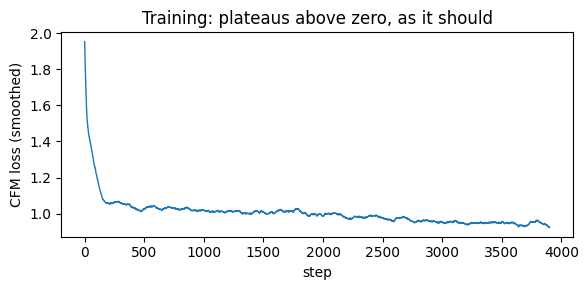

In [7]:
opt = torch.optim.Adam(net.parameters(), lr=LR)
history = []

for step in range(1, STEPS + 1):
    idx = torch.randint(0, N_SIM, (BATCH,), device=device)
    v1, xc = V_tilde[idx], X_cond[idx]        # target parameter, its observation

    v0 = torch.randn_like(v1)                 # noise endpoint
    t  = torch.rand(BATCH, 1, device=device)  # random time

    v_t = (1 - (1 - SIGMA_MIN) * t) * v0 + t * v1   # OT interpolant
    u   = v1 - (1 - SIGMA_MIN) * v0                 # target velocity (constant along path)

    loss = ((net(v_t, t, xc) - u) ** 2).mean()      # CFM objective

    opt.zero_grad(); loss.backward(); opt.step()
    history.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:5d} | loss {np.mean(history[-500:]):.4f}")

plt.figure(figsize=(6, 3))
plt.plot(np.convolve(history, np.ones(100)/100, mode="valid"), lw=1)
plt.xlabel("step"); plt.ylabel("CFM loss (smoothed)")
plt.title("Training: plateaus above zero, as it should"); plt.tight_layout(); plt.show()

## 8. Sampling the posterior

To draw from $p(V \mid X_{\text{obs}})$: start from Gaussian noise and integrate the learned ODE from
$t=0$ to $t=1$, holding $X_{\text{obs}}$ fixed as context, then map back through the sigmoid.

$$\frac{d\tilde{V}}{dt} = v_\theta(\tilde{V}, t, X_{\text{obs}}), \qquad \tilde{V}(0) \sim \mathcal{N}(0,1)$$

This is the same midpoint solver as Phase 1. Note how cheap this is: **no simulator calls at all.**

In [8]:
@torch.no_grad()
def sample_posterior(net, X_obs, n_samples, nfe=100):
    """
    Draw n_samples from p(V | X_obs) by integrating the conditional flow ODE.
    X_obs: (N_OBS,) single observation. Returns (n_samples,) in the ORIGINAL V space.
    """
    # Standardise with the TRAINING statistics -- never recomputed here.
    xc = torch.tensor((np.atleast_2d(X_obs) - X_MEAN) / X_STD,
                      dtype=torch.float32, device=device).repeat(n_samples, 1)

    v  = torch.randn(n_samples, 1, device=device)   # t = 0: pure noise
    dt = 1.0 / nfe
    for k in range(nfe):                            # midpoint (RK2) integration
        t  = torch.full((n_samples, 1), k * dt, device=device)
        k1 = net(v, t, xc)
        k2 = net(v + 0.5 * dt * k1, t + 0.5 * dt, xc)
        v  = v + dt * k2                            # t = 1: posterior sample (logit space)

    return to_constrained(v).cpu().numpy().ravel()  # back to [V_LO, V_HI]

print("Sampler ready.")

Sampler ready.


## 9. Check 1 — does the FM posterior match the analytic truth?

The decisive test. We fix $V^\star = 0.5$, simulate one observation $X_x$ from it, and overlay the FM
posterior on the exact one. If these disagree, nothing downstream is trustworthy.

V* = 0.5 -> X_x = [0.5369 0.5454 0.6434 0.4805 0.3564] | mean = 0.5125


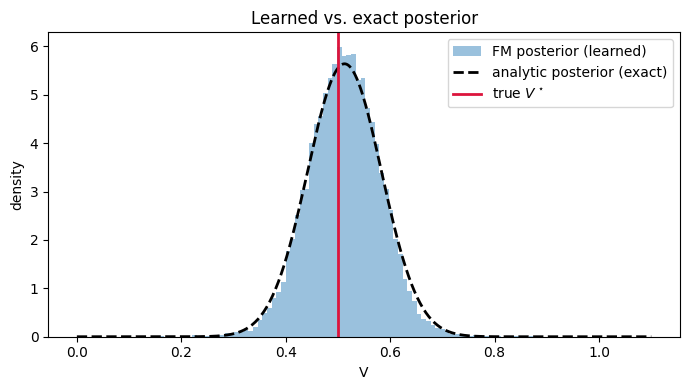


               mean      std
FM           0.5121   0.0684
analytic     0.5129   0.0704
theory       0.5125   0.0707

Note the posterior centres on Xbar, NOT on V* -- that is correct Bayesian behaviour.
The offset between Xbar and V* is the noise; the posterior width honestly reports it.


In [9]:
V_STAR = 0.5
rng_test = np.random.default_rng(0)             # separate stream: held-out

X_x = simulate(np.array([V_STAR]), rng_test)[0]
print("V* =", V_STAR, "-> X_x =", np.round(X_x, 4), "| mean =", round(X_x.mean(), 4))

fm_samples = sample_posterior(net, X_x, 20_000)
an_samples = analytic_posterior_samples(X_x, 20_000, rng_test)

v_grid = np.linspace(0.0, 1.1, 600)
plt.figure(figsize=(7, 4))
plt.hist(fm_samples, bins=80, density=True, alpha=0.45, label="FM posterior (learned)")
plt.plot(v_grid, analytic_posterior_pdf(v_grid, X_x), "k--", lw=2, label="analytic posterior (exact)")
plt.axvline(V_STAR, color="crimson", lw=2, label=r"true $V^\star$")
plt.xlabel("V"); plt.ylabel("density"); plt.legend()
plt.title("Learned vs. exact posterior"); plt.tight_layout(); plt.show()

print(f"\n{'':10s} {'mean':>8s} {'std':>8s}")
print(f"{'FM':10s} {fm_samples.mean():8.4f} {fm_samples.std():8.4f}")
print(f"{'analytic':10s} {an_samples.mean():8.4f} {an_samples.std():8.4f}")
print(f"{'theory':10s} {X_x.mean():8.4f} {S_TOT/np.sqrt(N_OBS):8.4f}")
print("\nNote the posterior centres on Xbar, NOT on V* -- that is correct Bayesian behaviour.")
print("The offset between Xbar and V* is the noise; the posterior width honestly reports it.")

## 10. The two metrics, side by side

We evaluate on ~500 **fresh** $(V^\star, X^\star)$ pairs — one observation is not an evaluation.

**Metric A — $\|V^k - V^\star\|$ (the originally proposed one).** Distance from a posterior draw to
the truth. Reported in three variants so the difference is explicit:
- a *single draw* $V^k$,
- the *posterior mean* $\hat{V}$ (the fair point estimate),
- the mean posterior *std* (the irreducible floor).

**Metric B — calibration.** Is the *uncertainty* itself honest?
- **Coverage**: the 90% credible interval should contain $V^\star$ 90% of the time.
- **SBC** (simulation-based calibration, Talts et al. 2018): the rank of $V^\star$ among its own
  posterior samples must be **uniform**. A hump in the middle $\Rightarrow$ posteriors too wide
  (under-confident); a U-shape $\Rightarrow$ too narrow (over-confident — the classic failure of this
  family of methods).

**What to expect, and why it is the point.** Metric A cannot reach zero: five noisy observations carry
finite information. Theory predicts the single-draw error is $\approx\sqrt{2}\times$ the
posterior-mean error, because a draw carries the posterior's spread *on top of* the mean's error. So
Metric A looking "bad" while Metric B says "calibrated" is not a contradiction — it means **the model
is right and the data is uninformative.** Only Metric B can tell those apart, which is exactly why we
run both.

--- Metric A: distance to truth ---
  single draw  |V^k - V*|   : 0.0717
  posterior mean |V_hat - V*|: 0.0526   <- the fair point estimate
  mean posterior std         : 0.0648   <- irreducible floor
  ratio single/mean          : 1.364   (theory: ~1.41)

--- Metric B: calibration ---
  90% credible coverage: 0.888   (ideal 0.900)
  SBC mean rank        : 100.0     (ideal 100.0)


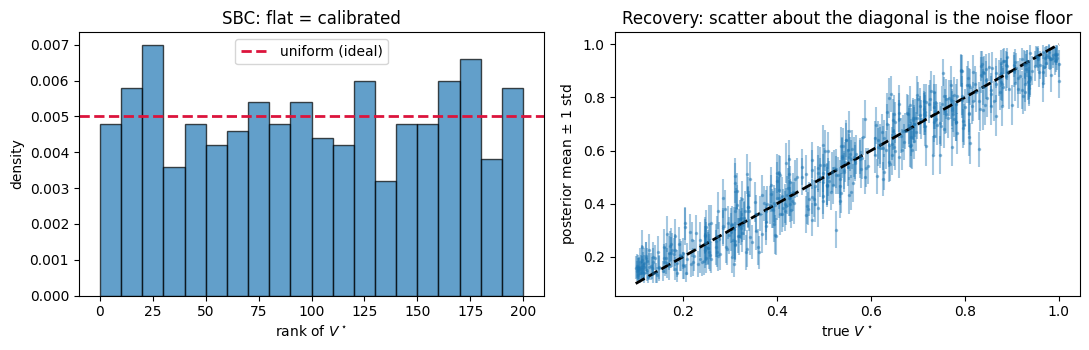

In [10]:
M, L = 500, 200                                  # M held-out truths, L posterior samples each

V_true = sample_prior(M, rng_test)
X_test = simulate(V_true, rng_test)
posts  = np.stack([sample_posterior(net, X_test[m], L) for m in range(M)])   # (M, L)

# ---- Metric A ----
err_single = np.abs(posts[:, 0] - V_true).mean()
err_mean   = np.abs(posts.mean(1) - V_true).mean()
post_std   = posts.std(1).mean()

print("--- Metric A: distance to truth ---")
print(f"  single draw  |V^k - V*|   : {err_single:.4f}")
print(f"  posterior mean |V_hat - V*|: {err_mean:.4f}   <- the fair point estimate")
print(f"  mean posterior std         : {post_std:.4f}   <- irreducible floor")
print(f"  ratio single/mean          : {err_single/err_mean:.3f}   (theory: ~1.41)")

# ---- Metric B ----
lo, hi = np.percentile(posts, 5, axis=1), np.percentile(posts, 95, axis=1)
coverage = np.mean((lo <= V_true) & (V_true <= hi))
ranks = (posts < V_true[:, None]).sum(1)

print("\n--- Metric B: calibration ---")
print(f"  90% credible coverage: {coverage:.3f}   (ideal 0.900)")
print(f"  SBC mean rank        : {ranks.mean():.1f}     (ideal {L/2:.1f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(ranks, bins=20, range=(0, L), density=True, alpha=0.7, edgecolor="k")
ax[0].axhline(1.0 / L, color="crimson", ls="--", lw=2, label="uniform (ideal)")
ax[0].set_xlabel(r"rank of $V^\star$"); ax[0].set_ylabel("density")
ax[0].set_title("SBC: flat = calibrated"); ax[0].legend()

ax[1].errorbar(V_true, posts.mean(1), yerr=posts.std(1), fmt=".", alpha=0.4, ms=3)
ax[1].plot([V_LO, V_HI], [V_LO, V_HI], "k--", lw=2)
ax[1].set_xlabel(r"true $V^\star$"); ax[1].set_ylabel(r"posterior mean $\pm$ 1 std")
ax[1].set_title("Recovery: scatter about the diagonal is the noise floor")
plt.tight_layout(); plt.show()

## 11. What carries over to Heston, and what does not

**Unchanged** — every cell above except one:

- the prior $\to$ simulator $\to$ joint-samples logic (Section 1),
- the logit transform (one box per parameter),
- the velocity network, the CFM loss, the ODE sampler,
- both metrics.

**The single change:** `simulate()` becomes the full-truncation Euler Monte-Carlo — price the
$(K,T)$ grid, invert to implied vols, add $E$. The Brownian paths take the role of $W$.

**What changes in kind, and must be planned for:**

| | toy | Heston |
|---|---|---|
| $V$ | 1-D | 5-D: $(\kappa, \theta, \xi, \rho, v_0)$ — needs **2-D marginals**, not just intervals |
| $j$ | design points | the 5 maturities; $X^j$ is a whole smile, so $X$ is a surface |
| cost of one $F$ | microseconds | Monte-Carlo — simulate **all maturities from one path set** |
| analytic posterior | exists | **does not exist** — Metric B is then the *only* correctness check |
| identifiability | clean | $\kappa$–$\theta$ ridge expected: broad, correlated posterior. If it comes out narrow and round, something is wrong |

**Two rules the toy makes concrete:**

1. **Train and deploy must match exactly.** Same $\sigma$, same standardisation, and — new for Heston
   — the same `n_paths`, since finite Monte-Carlo makes $F$ itself stochastic. Any mismatch is
   misspecification, and the posterior is then confidently wrong with no warning.
2. **Once the analytic referee disappears, calibration is all you have.** Metric B is not optional
   decoration for Heston; it is the entire correctness argument.

**And the known cliff.** Steps 1–3 are self-consistent synthetic: data generated by the same model we
infer with. Deploying on the **real NIFTY surface** breaks that — Phase 3 already established that
one-factor Heston cannot span 0.02y–0.40y. Under misspecification the posterior stays narrow and is
simply wrong. Either restrict to the 0.08–0.40y band, or report the misspecification as a finding.
That discontinuity should be explicit, not discovered later.

**Next:** Step 2 — Heston with $V = (v_0, \theta)$ only, $\kappa, \xi, \rho$ fixed at the Phase-3
calibrated values. A 2-D posterior can be plotted and eyeballed directly. That is the real go/no-go
before the full 5-D.